In [1]:
import pandas as pd
import numpy as np

In [2]:
df  = pd.read_csv("powerplant.csv", sep= "\t")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => temperature
# V => vacuum
# AP => pressure 
# RH => Humidity 

# PE => produces Energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
# Let drop X value from the dataframe and store in another column
X = df.drop("PE", axis=1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# split our data 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y , test_size = 0.2, random_state = 42
)

In [9]:
df.shape


(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Data --> Tensor

In [11]:
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled , dtype=torch.float32)
# here up X_train_scaled is an numpy value that is in array form os we dont have to use .values 
y_train_tensor = torch.tensor(y_train.values, dtype =torch.float32).view(-1,1)  
# up we convert a 1D array into 2D array by using .view()
# --this is a pandas value that does not in the form of array so we have to use  .

X_test_tensor = torch.tensor(X_test_scaled, dtype= torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1, 1)

In [12]:
type(y_train)

pandas.core.series.Series

In [13]:
y_train.shape

(7654,)

In [14]:
y_test_tensor.shape

torch.Size([1914, 1])

# Dataset and DataLoader

In [15]:
from torch.utils.data import TensorDataset, DataLoader

# train_dataset = TensorDataset(input_features, output_features)

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [16]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# Deep Learning 

In [17]:
# define  our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
        # 1st hidden
        # nn.Liner(input layers features , it's output layer features)
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

        # 2nd hidden layer 
            nn.Linear(6,6),
            nn.ReLU(),

        # output layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x) 
        # -- in pytorch forward propagation we just need this forward function to get the ouput 
        # -- but in backward propagation we don't need this function 
        

In [18]:
import torch.optim as optim # ---as a optimizer

model  = ANN()

# loss , optimizer 
crietrion = nn.MSELoss() # --Means squared error
optimizer = optim.Adam(model.parameters())

In [37]:
#train The ANN 
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train() # this a training mode where learning happens,wieght and bias get updated with futher process of batches 
    running_loss = 0.0  # save total training loss for 1 epoch

    for xb , yb in train_loader:
         # xb  = features of 1 batch
        # yb = labels of 1 batch 
        optimizer.zero_grad() # it is used to make gradient for each previous batches should be zero so that they caanot be accumulated and we could get a fresh or new gradient 

        outputs = model(xb) # forward prop... predicted outputs for this batch 
        loss = crietrion(outputs,yb) # compute loss per batch
        loss .backward()  # back propagation .. compute gradient
        optimizer.step()  # params udated those are leanable params like wieghts and bias get uodated through this 

        running_loss += loss.item() # runnning loss is loss for al the batches .loss is a tensor  convert into(=>) py float

    epoch_train_loss = running_loss / len(train_loader) # average loss per batch = train loss
    train_losses.append(epoch_train_loss)

    # validation -- on testing data
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():  # no gradients compute
        for xb ,yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)  # len(test_loader)-- gives the total no of batches
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #we save in .pt or .pth extension

epoch 1/100 ==> train loss = $20.344035998980203 & val loss = $18.610462188720703
epoch 2/100 ==> train loss = $20.26246079802513 & val loss = $18.39303970336914
epoch 3/100 ==> train loss = $20.21155719359716 & val loss = $18.70331382751465
epoch 4/100 ==> train loss = $20.388827619949975 & val loss = $18.577207565307617
epoch 5/100 ==> train loss = $20.232036832968394 & val loss = $18.950345993041992
epoch 6/100 ==> train loss = $20.355348388353985 & val loss = $18.464916229248047
epoch 7/100 ==> train loss = $20.426627298196156 & val loss = $19.24687385559082
epoch 8/100 ==> train loss = $20.278123732407888 & val loss = $18.338376998901367
epoch 9/100 ==> train loss = $21.4356918712457 & val loss = $19.570301055908203
epoch 10/100 ==> train loss = $20.427296463648478 & val loss = $18.891878128051758
epoch 11/100 ==> train loss = $20.376873608430227 & val loss = $18.702739715576172
epoch 12/100 ==> train loss = $20.296956125895182 & val loss = $19.298620223999023
epoch 13/100 ==> tra

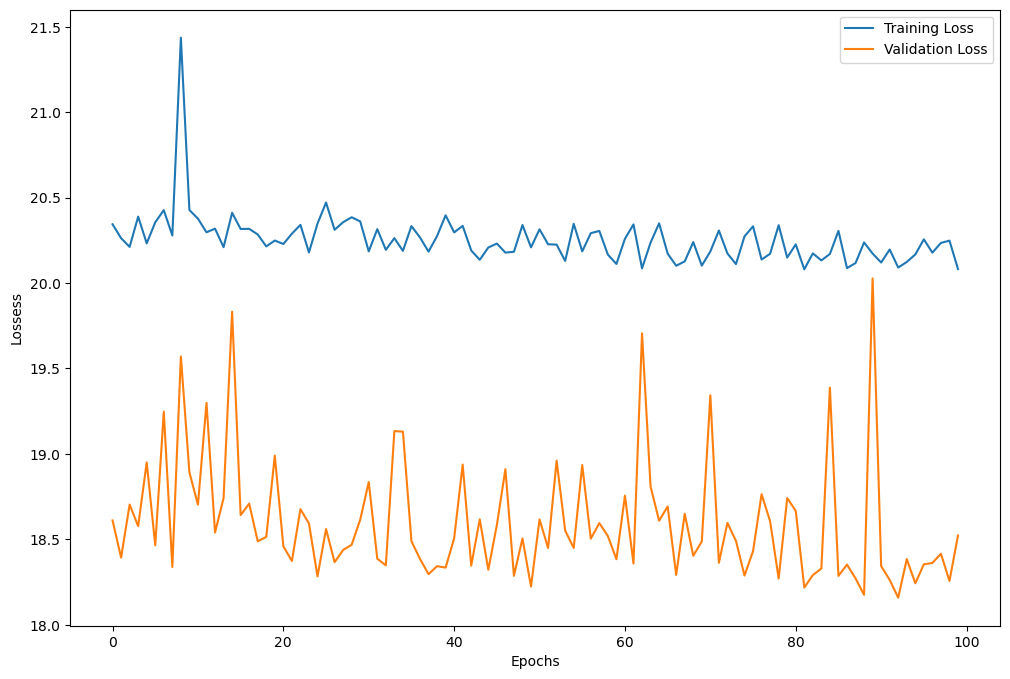

In [38]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"] , label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Lossess")

plt.legend()

In [39]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [41]:
# Evaluation 

model.eval()
with torch.no_grad():  # we do not have to calculate the gradient that save our computation time 
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)
    # now we compare these val with actual o/p values

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE" , train_mse_loss.item())
print("Testing MSE", test_mse_loss.item())

Training MSE 19.830678939819336
Testing MSE 18.160472869873047


In [42]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9365338348887201


In [44]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns  = ["Actual Values"])

pd.concat([predicted_df , actual_df], axis=1)

,Predicted Values,Actual Values
0,434.862549,433.27
1,436.591248,438.16
2,461.192078,458.42
3,476.440369,480.82
4,434.777710,441.41
...,...,...
1909,451.265930,456.70
1910,431.190125,438.04
1911,467.698822,467.80
1912,430.606934,437.14
